# SARIMA - Forecast de Consumo Eléctrico Horario

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Series Temporales · ARIMA/SARIMA

---

## Contexto de negocio

Una empresa energética necesita anticipar su consumo eléctrico hora a hora para:

- **Optimizar la planificación de potencia** y evitar costes innecesarios.
- **Preparar los recursos energéticos** ante picos de demanda.
- **Detectar comportamientos anómalos** comparando el consumo real con el esperado.

La pregunta analítica es:

**¿Podemos predecir el consumo de las próximas horas capturando correctamente el patrón diario?**

El objetivo no es únicamente obtener una buena métrica, sino generar una previsión que pueda utilizarse como apoyo a la planificación energética.

## Objetivo y elección del modelo

El consumo eléctrico presenta una característica especialmente interesante: **el comportamiento de una hora está relacionado con el de horas anteriores y con la misma hora de días anteriores**.

Por ejemplo, el consumo de las 10:00 suele parecerse más al consumo de las 10:00 del día anterior que al de las 03:00.

Por ello utilizamos **SARIMA**, un modelo que permite combinar:

- Dependencia temporal.
- Autocorrelación.
- Estacionalidad.
- Intervalos de confianza para las previsiones.

En este caso utilizaremos una **estacionalidad de 24 horas (`s=24`)**, correspondiente al ciclo diario.

# Librerías y configuración visual

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Estilo visual -- sistema de color validado (consejo UX/UI Data)
from matplotlib.colors import LinearSegmentedColormap

BACKGROUND    = "#fbfbfb"
PURPLE        = "#7a7bff"
PURPLE_LIGHT  = "#9b9cff"
POSITIVE      = "#6b8158"
NEGATIVE      = "#c34031"
NEUTRAL_BAR   = "#d9d9d9"
NEUTRAL_LINE  = "#8f8c9e"
CONTEXT_LINES = [NEUTRAL_LINE, "#a89a8a", "#7d94a8"]
INK           = "#111111"
MUTED         = "#707070"

SEQUENTIAL_PURPLE = LinearSegmentedColormap.from_list(
    "borja_sequential_purple", [BACKGROUND, PURPLE]
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "sans-serif",
    "font.size": 10,
    "grid.color": "#f0f0f0",
    "grid.linewidth": 0.5,
})

pd.set_option("display.max_columns", None)

## Carga y exploración inicial

In [2]:
# Carga de datos

df = pd.read_excel(
    "electricidad.xlsx",
    sheet_name="consumo_electrico",
    index_col="periodo",
    parse_dates=True
)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Comprobar frecuencia antes de forzarla
frecuencia_original = pd.infer_freq(df.index)

print(f"Registros originales: {len(df)}")
print(f"Periodo:              {df.index.min()} -> {df.index.max()}")
print(f"Frecuencia detectada:  {frecuencia_original}")

# Convertimos la serie a frecuencia horaria explícita.
# Si existiera alguna hora ausente, aparecerá como NaN y no se ocultará.
df = df.asfreq("h")

print(f"Registros tras asfreq: {len(df)}")
print(f"Horas con valores nulos: {df['consumo'].isna().sum()}")

if df["consumo"].isna().any():
    print("\nSe han detectado horas sin dato.")
    print("Se interpolan únicamente para mantener la continuidad temporal.")
    df["consumo"] = df["consumo"].interpolate(method="time")

print("\nResumen estadístico:")
display(df.describe().round(2))

Registros originales: 719
Periodo:              2025-01-01 00:00:00 -> 2025-01-30 22:00:00
Frecuencia detectada:  h
Registros tras asfreq: 719
Horas con valores nulos: 0

Resumen estadístico:


,consumo
count,719.00
mean,54.95
std,11.45
min,38.36
25%,45.03
50%,53.26
75%,62.74
max,81.37


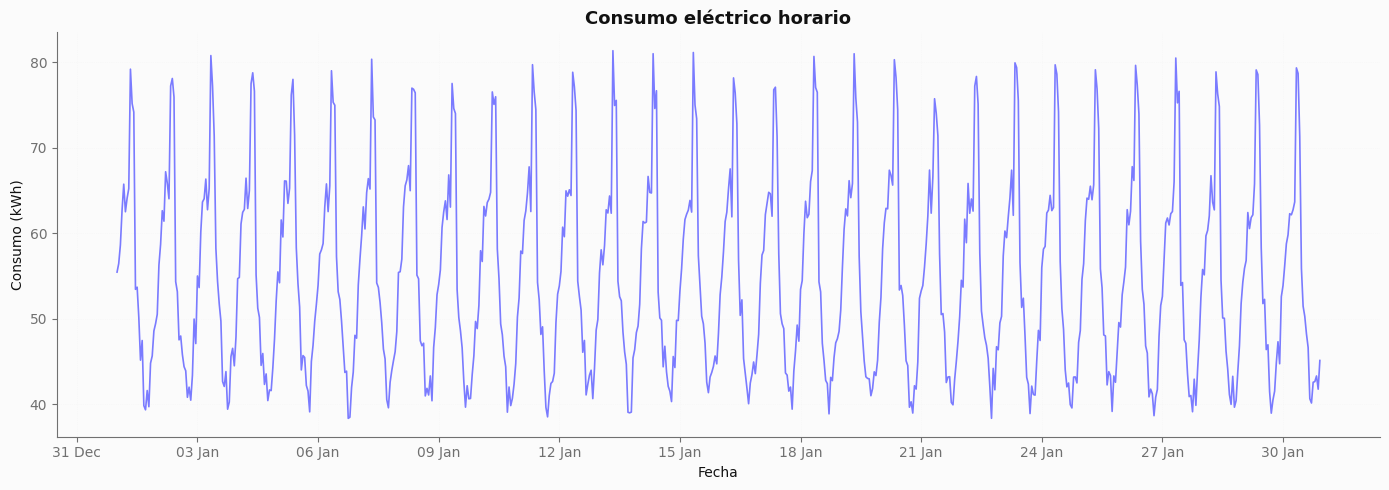

In [3]:
# Evolución del consumo

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df.index,
    df["consumo"],
    color=PURPLE,
    linewidth=1.2
)

ax.set_title("Consumo eléctrico horario")
ax.set_xlabel("Fecha")
ax.set_ylabel("Consumo (kWh)")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

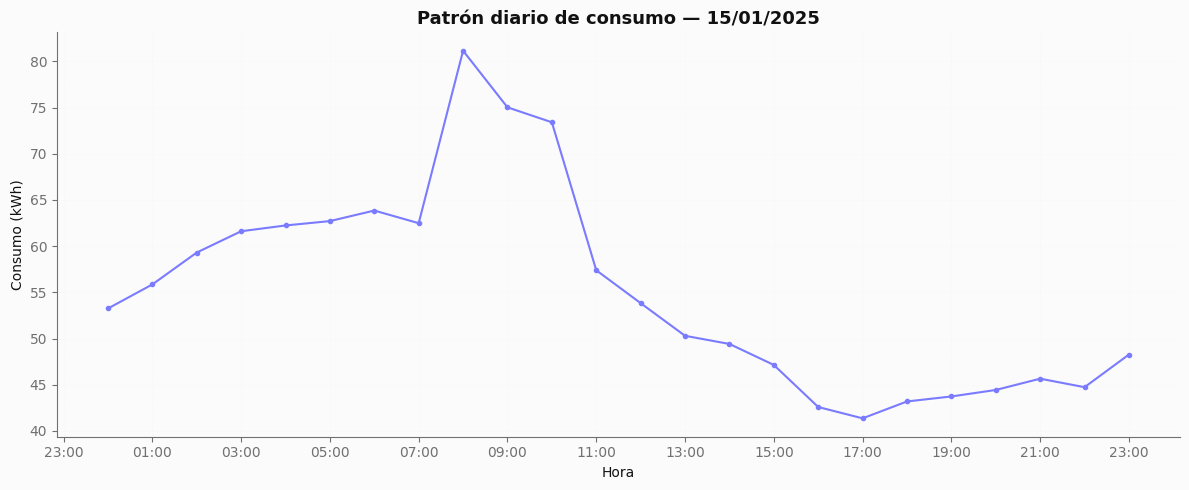

In [4]:
# Patrón de un día

dia_objetivo = df.index.normalize().unique()[min(14, len(df.index.normalize().unique()) - 1)]
un_dia = df.loc[df.index.normalize() == dia_objetivo]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    un_dia.index,
    un_dia["consumo"],
    color=PURPLE,
    marker="o",
    markersize=3,
    linewidth=1.5
)

ax.set_title(f"Patrón diario de consumo — {dia_objetivo.strftime('%d/%m/%Y')}")
ax.set_xlabel("Hora")
ax.set_ylabel("Consumo (kWh)")

ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

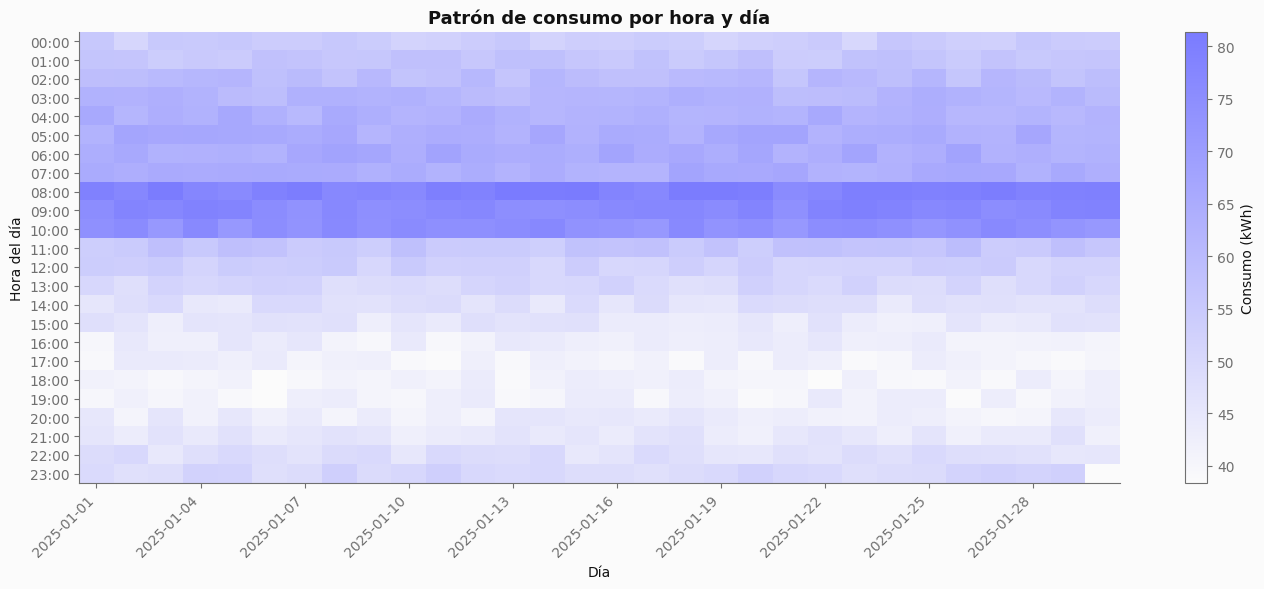

In [5]:
# Heatmap hora x día

df_heat = df.copy()
df_heat["hora"] = df_heat.index.hour
df_heat["dia"] = df_heat.index.date

pivot = df_heat.pivot_table(
    values="consumo",
    index="hora",
    columns="dia",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    interpolation="nearest",
    cmap=SEQUENTIAL_PURPLE
)

ax.set_title("Patrón de consumo por hora y día")
ax.set_xlabel("Día")
ax.set_ylabel("Hora del día")

ax.set_yticks(range(24))
ax.set_yticklabels([f"{h:02d}:00" for h in range(24)])

step = max(1, len(pivot.columns) // 10)
ax.set_xticks(range(0, len(pivot.columns), step))
ax.set_xticklabels(
    [str(d) for d in pivot.columns[::step]],
    rotation=45,
    ha="right"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Consumo (kWh)")

plt.tight_layout()
plt.show()

## Preparación de datos: separación temporal


In [6]:
# Train / Test cronológico

split = int(len(df) * 0.80)

train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

print(f"Train: {len(train)} horas | {train.index.min()} -> {train.index.max()}")
print(f"Test:  {len(test)} horas | {test.index.min()} -> {test.index.max()}")
print(f"Proporción: {len(train)/len(df):.0%} train / {len(test)/len(df):.0%} test")

Train: 575 horas | 2025-01-01 00:00:00 -> 2025-01-24 22:00:00
Test:  144 horas | 2025-01-24 23:00:00 -> 2025-01-30 22:00:00
Proporción: 80% train / 20% test


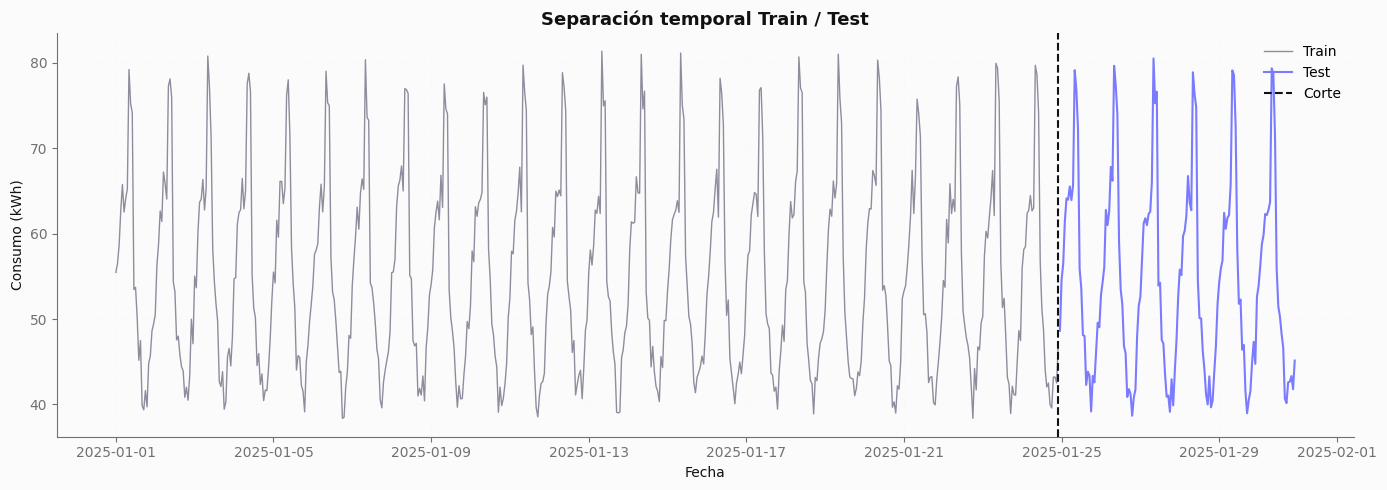

In [7]:
# Visualización de Train / Test

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    train.index,
    train["consumo"],
    color=NEUTRAL_LINE,
    linewidth=1.0,
    label="Train"
)

ax.plot(
    test.index,
    test["consumo"],
    color=PURPLE,
    linewidth=1.5,
    label="Test"
)

ax.axvline(
    train.index[-1],
    color=INK,
    linestyle="--",
    linewidth=1.5,
    label="Corte"
)

ax.set_title("Separación temporal Train / Test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Consumo (kWh)")
ax.legend(frameon=False)

ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

## Análisis de estacionariedad

Antes de definir el modelo comprobamos si la serie presenta una tendencia que requiera diferenciación.

Utilizamos el **test de Dickey-Fuller aumentado (ADF)**:

- `p < 0,05` → rechazamos la hipótesis de raíz unitaria → evidencia de estacionariedad.
- `p >= 0,05` → no podemos rechazar la no estacionariedad.

El resultado determinará el valor de `d`.

In [8]:
# Test ADF

resultado_adf = adfuller(train["consumo"])

estadistico_adf = resultado_adf[0]
p_valor_adf = resultado_adf[1]

print("Test de Dickey-Fuller aumentado")
print(f"Estadístico ADF: {estadistico_adf:.4f}")
print(f"p-valor:         {p_valor_adf:.6f}")

if p_valor_adf < 0.05:
    d = 0
    print("\nConclusión: existe evidencia de estacionariedad.")
    print("Se utiliza d = 0.")
else:
    d = 1
    print("\nConclusión: no hay evidencia suficiente de estacionariedad.")
    print("Se utilizaría d = 1 como punto de partida.")

print(f"\nValor utilizado para d: {d}")

Test de Dickey-Fuller aumentado
Estadístico ADF: -20.0618
p-valor:         0.000000

Conclusión: existe evidencia de estacionariedad.
Se utiliza d = 0.

Valor utilizado para d: 0


## Identificación de parámetros: ACF y PACF

La **ACF** ayuda a identificar la estructura de medias móviles (`q`) y la **PACF** la estructura autorregresiva (`p`).

Además, los picos alrededor de los retardos **24, 48, 72...** permiten comprobar la presencia de una estacionalidad diaria.

En este caso partimos de:

**SARIMA(1,0,0)(1,0,1,24)**

como modelo candidato, apoyándonos en la estructura observada en ACF/PACF y en el ciclo diario.

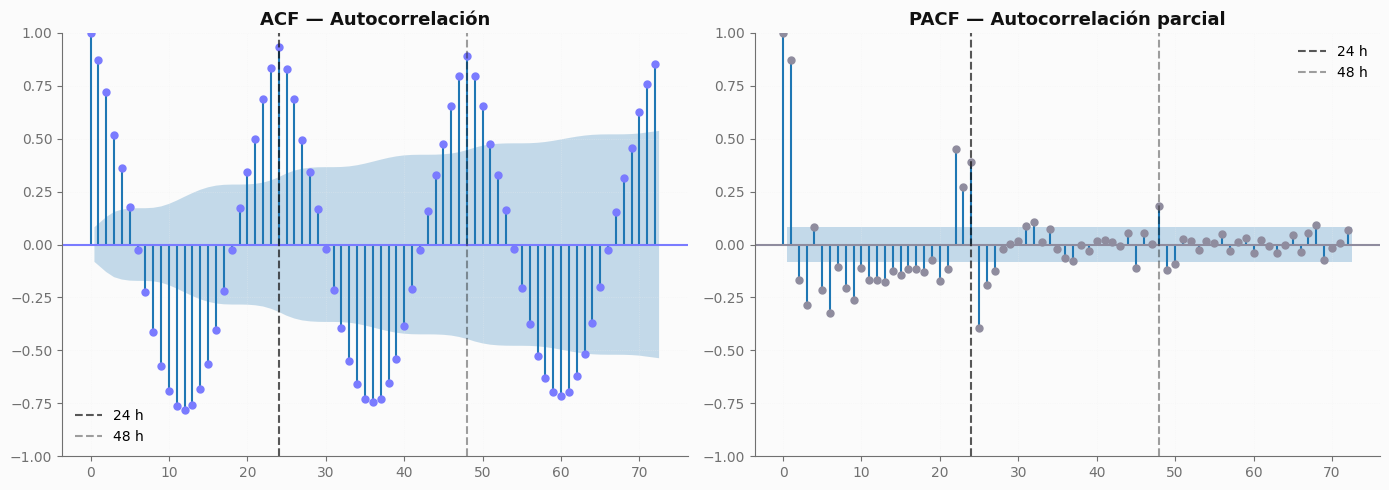

In [9]:
# ACF y PACF

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(
    train["consumo"],
    lags=72,
    ax=axes[0],
    color=PURPLE
)

axes[0].set_title("ACF — Autocorrelación")
axes[0].axvline(24, color=INK, linestyle="--", alpha=0.7, label="24 h")
axes[0].axvline(48, color=INK, linestyle="--", alpha=0.4, label="48 h")
axes[0].legend(frameon=False)

plot_pacf(
    train["consumo"],
    lags=72,
    ax=axes[1],
    color=CONTEXT_LINES[0]
)

axes[1].set_title("PACF — Autocorrelación parcial")
axes[1].axvline(24, color=INK, linestyle="--", alpha=0.7, label="24 h")
axes[1].axvline(48, color=INK, linestyle="--", alpha=0.4, label="48 h")
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

## Modelo SARIMA

### Parámetros seleccionados

| Componente | Parámetro | Valor | Interpretación |
|:-----------|:----------|------:|:---------------|
| AR no estacional | `p` | 1 | Dependencia con la hora anterior |
| Diferenciación | `d` | 0 | Serie estacionaria |
| MA no estacional | `q` | 0 | Sin componente MA no estacional |
| AR estacional | `P` | 1 | Dependencia con el mismo momento del ciclo anterior |
| Diferenciación estacional | `D` | 0 | No se aplica diferenciación estacional |
| MA estacional | `Q` | 1 | Corrección del error estacional |
| Periodo | `s` | 24 | Ciclo diario |

### Modelo

**SARIMA(1,0,0)(1,0,1,24)**


In [10]:
# Entrenamiento SARIMA

modelo = SARIMAX(
    train["consumo"],
    order=(1, 0, 0),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_fit = modelo.fit(disp=False)

print(resultado_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                              consumo   No. Observations:                  575
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 24)   Log Likelihood               -1118.869
Date:                              Fri, 11 Sep 2026   AIC                           2245.738
Time:                                      12:04:23   BIC                           2262.978
Sample:                                  01-01-2025   HQIC                          2252.475
                                       - 01-24-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0139      0.042     -0.329      0.742      -0.097       0.069
ar.S.L24       0.99

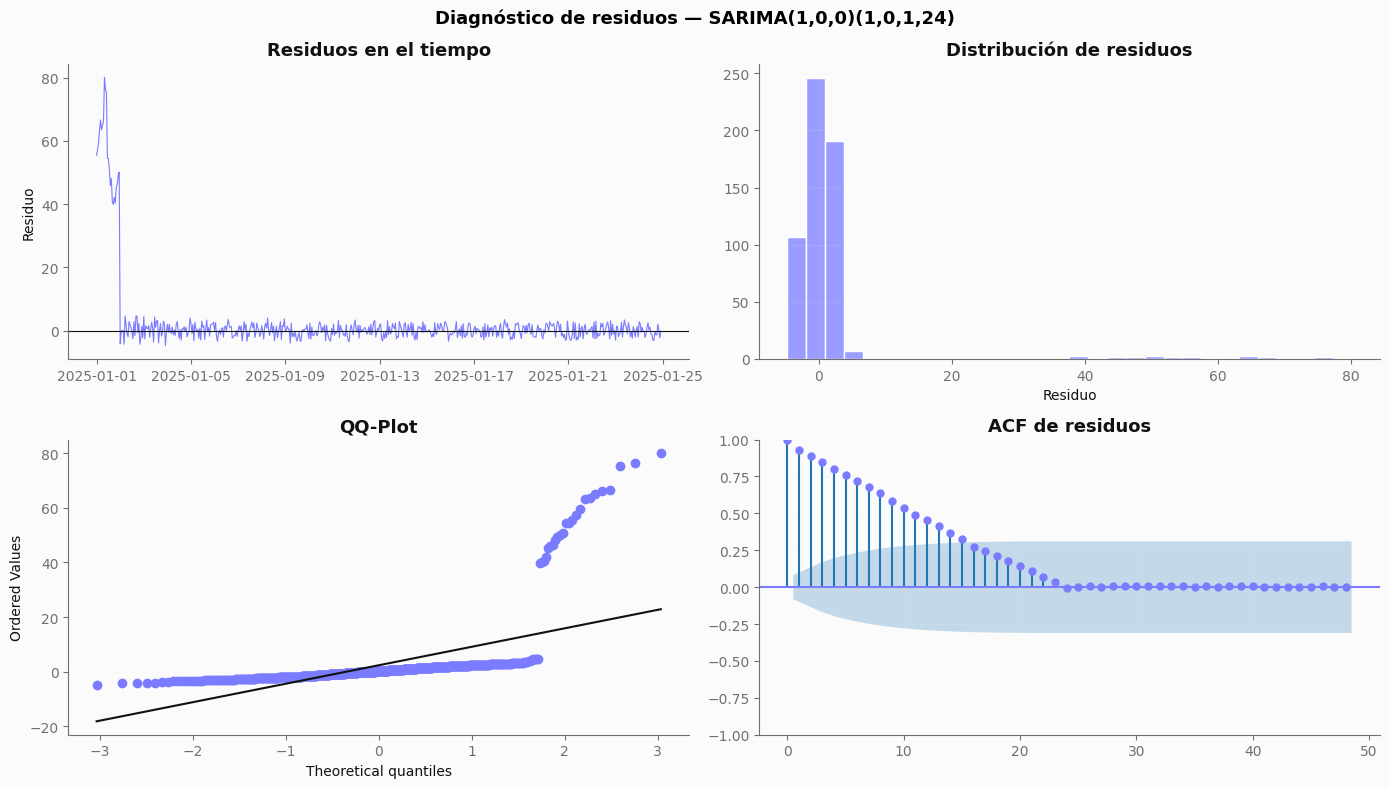

In [11]:
# Diagnóstico de residuos

resid = resultado_fit.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(
    resid.index,
    resid,
    color=PURPLE,
    linewidth=0.8
)
axes[0, 0].axhline(0, color=INK, linewidth=0.8)
axes[0, 0].set_title("Residuos en el tiempo")
axes[0, 0].set_ylabel("Residuo")

axes[0, 1].hist(
    resid,
    bins=30,
    color=PURPLE_LIGHT,
    edgecolor="white"
)
axes[0, 1].set_title("Distribución de residuos")
axes[0, 1].set_xlabel("Residuo")

stats.probplot(
    resid,
    dist="norm",
    plot=axes[1, 0]
)
axes[1, 0].get_lines()[0].set_color(PURPLE)
axes[1, 0].get_lines()[1].set_color(INK)
axes[1, 0].set_title("QQ-Plot")

plot_acf(
    resid,
    lags=min(48, len(resid)//3),
    ax=axes[1, 1],
    color=PURPLE
)
axes[1, 1].set_title("ACF de residuos")

for ax in axes.ravel():
    ax.grid(True, linestyle=":", alpha=0.5)

plt.suptitle(
    "Diagnóstico de residuos — SARIMA(1,0,0)(1,0,1,24)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretación del diagnóstico

In [12]:
# Test de Ljung-Box

ljung = acorr_ljungbox(
    resid,
    lags=[24, 48],
    return_df=True
)

print("Test de Ljung-Box")
display(ljung.round(4))

if (ljung["lb_pvalue"] > 0.05).all():
    print(
        "\nNo se detecta autocorrelación significativa en los residuos "
        "a los retardos analizados."
    )
else:
    print(
        "\nExisten indicios de autocorrelación residual. "
        "El modelo podría mejorarse."
    )

Test de Ljung-Box


,lb_stat,lb_pvalue
24,3915.6519,0.0
48,3916.0969,0.0



Existen indicios de autocorrelación residual. El modelo podría mejorarse.


## Evaluación sobre el conjunto de test

La evaluación se realiza exclusivamente sobre datos que **no han sido utilizados para entrenar el modelo**.

Utilizamos:

- **MAE:** error medio absoluto en kWh.
- **RMSE:** penaliza más los errores grandes.
- **MAPE:** error porcentual medio.
- **Error relativo:** MAE respecto al consumo medio del periodo de test.

Para este caso, el **MAPE** es especialmente fácil de interpretar porque permite expresar el error de previsión como porcentaje del consumo real.

In [13]:
# Predicción sobre test y métricas

pred = resultado_fit.get_forecast(steps=len(test))

pred_media = pred.predicted_mean
pred_ic = pred.conf_int()

mae = mean_absolute_error(
    test["consumo"],
    pred_media
)

rmse = np.sqrt(
    mean_squared_error(
        test["consumo"],
        pred_media
    )
)

media_test = test["consumo"].mean()

mape = (
    np.mean(
        np.abs(
            (test["consumo"] - pred_media) / test["consumo"]
        )
    ) * 100
)

error_relativo = (mae / media_test) * 100

print("Métricas de evaluación — conjunto de test")
print(f"MAE:             {mae:.2f} kWh")
print(f"RMSE:            {rmse:.2f} kWh")
print(f"Consumo medio:   {media_test:.2f} kWh")
print(f"MAPE:            {mape:.2f}%")
print(f"Error relativo:  {error_relativo:.2f}%")

Métricas de evaluación — conjunto de test
MAE:             1.46 kWh
RMSE:            1.70 kWh
Consumo medio:   54.78 kWh
MAPE:            2.79%
Error relativo:  2.67%


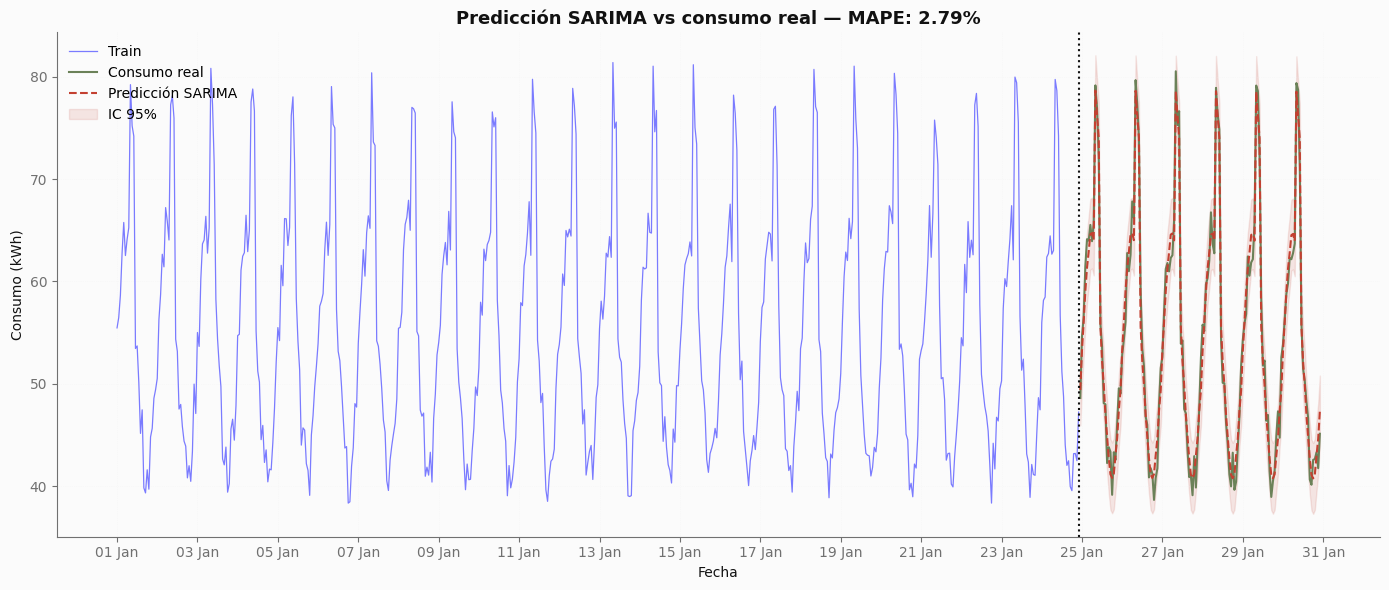

In [19]:
# Predicción vs realidad

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    train.index,
    train["consumo"],
    color=NEUTRAL_LINE,
    linewidth=0.9,
    label="Train"
)

ax.plot(
    test.index,
    test["consumo"],
    color=INK,
    linewidth=1.5,
    label="Consumo real"
)

ax.plot(
    test.index,
    pred_media,
    color=PURPLE,
    linewidth=1.5,
    linestyle="--",
    label="Predicción SARIMA"
)

ax.fill_between(
    test.index,
    pred_ic.iloc[:, 0],
    pred_ic.iloc[:, 1],
    color=PURPLE,
    alpha=0.12,
    label="IC 95%"
)

ax.axvline(
    train.index[-1],
    color=INK,
    linestyle=":",
    linewidth=1.5
)

ax.set_title(
    f"Predicción SARIMA vs consumo real — MAPE: {mape:.2f}%"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Consumo (kWh)")
ax.legend(frameon=False)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

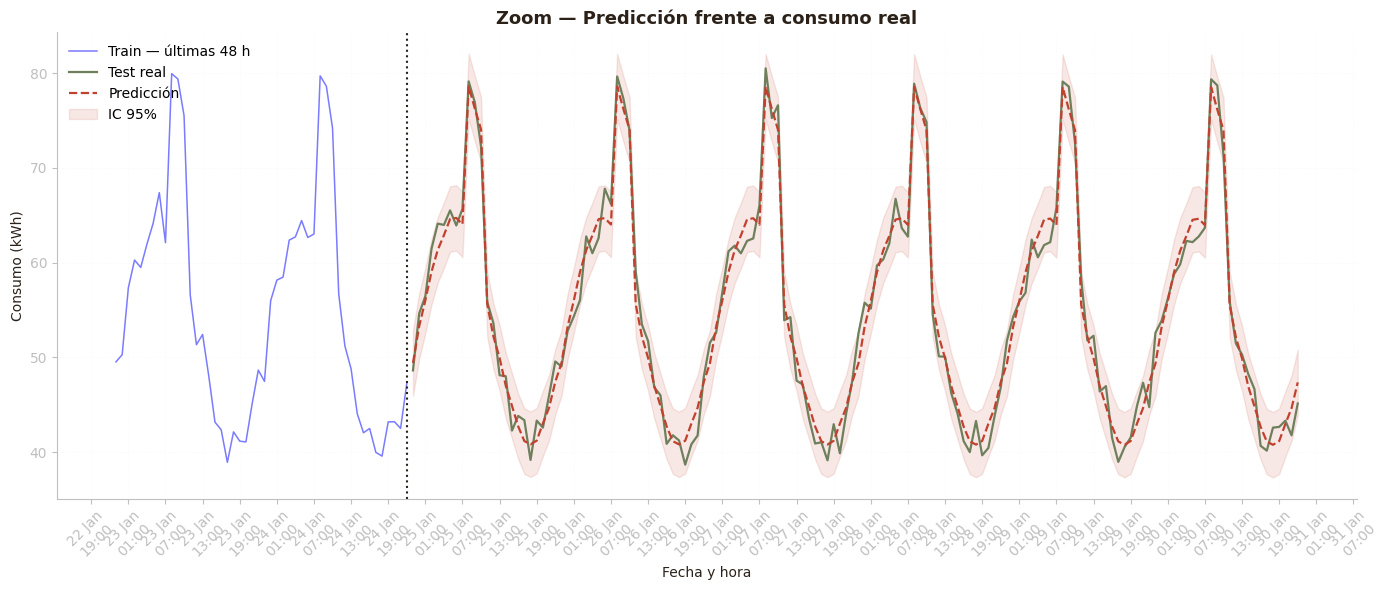

In [ ]:
# Zoom sobre el periodo de test

ventana_contexto = min(48, len(train))
inicio = train.index[-ventana_contexto]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    train.loc[inicio:, "consumo"],
    color=NEUTRAL_LINE,
    linewidth=1.1,
    label=f"Train — últimas {ventana_contexto} h"
)

ax.plot(
    test["consumo"],
    color=INK,
    linewidth=1.6,
    label="Test real"
)

ax.plot(
    pred_media,
    color=PURPLE,
    linewidth=1.6,
    linestyle="--",
    label="Predicción"
)

ax.fill_between(
    test.index,
    pred_ic.iloc[:, 0],
    pred_ic.iloc[:, 1],
    color=PURPLE,
    alpha=0.12,
    label="IC 95%"
)

ax.axvline(
    train.index[-1],
    color=INK,
    linestyle=":",
    linewidth=1.5
)

ax.set_title("Zoom — Predicción frente a consumo real")
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Consumo (kWh)")
ax.legend(frameon=False)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))

ax.grid(True, linestyle=":", alpha=0.5)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Conclusión y recomendaciones

### Conclusión

El consumo eléctrico presenta una **estacionalidad diaria clara**, lo que hace que SARIMA sea una elección adecuada para este problema.

El modelo aprovecha tanto la dependencia entre horas consecutivas como la repetición del patrón cada 24 horas. La evaluación sobre el conjunto de test permite comprobar si esta estructura se mantiene fuera de la muestra utilizada para entrenar.

El **MAPE** es especialmente útil desde el punto de vista de negocio: permite traducir el rendimiento del modelo a un porcentaje de error fácilmente interpretable.

### Recomendaciones

**1. Planificación energética**

Utilizar las previsiones para anticipar picos de demanda y mejorar la planificación de recursos.

**2. Gestión de potencia**

Combinar la previsión puntual con el **intervalo de confianza del 95%** para tomar decisiones más conservadoras ante posibles picos.

**3. Detección de anomalías**

Comparar posteriormente el consumo real con el intervalo previsto. Desviaciones persistentes pueden utilizarse como señal para investigar comportamientos anómalos.

**4. Evolución del modelo**

El dataset utilizado es relativamente corto. Para llevar este modelo a producción sería recomendable disponer de varios meses o años de histórico, incorporar festivos y variables externas —como temperatura o calendario laboral— y comparar SARIMA con modelos como XGBoost o enfoques más avanzados de forecasting.

### Hallazgo clave

**El patrón diario es suficientemente estable como para que un modelo SARIMA pueda utilizar la información histórica para anticipar el consumo futuro y convertir esa previsión en una herramienta de planificación energética.**